# RL & MDP Project: LunarLander


In [1]:
# If needed, install dependencies (uncomment as appropriate)
# !pip install "gymnasium[box2d]" imageio

import numpy as np
import gymnasium as gym
import imageio
from base64 import b64encode
from IPython.display import HTML

ENV_IDS = ["LunarLander-v3", "LunarLander-v2"] 


def make_lander_env(render_mode=None):
    last_error = None
    for env_id in ENV_IDS:
        try:
            if render_mode is None:
                env = gym.make(env_id)
            else:
                env = gym.make(env_id, render_mode=render_mode)
            print(f"Using env_id={env_id!r}, render_mode={render_mode!r}")
            return env
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not create any LunarLander environment from {ENV_IDS}: {last_error}")


def record_video(env, policy, out_directory, fps=30, random_action=False, max_steps=1600, action_set=None):
    images = []
    total_reward = 0.0
    terminated = False
    truncated = False
    obs, info = env.reset()
    img = env.render()
    images.append(img)
    t = 0
    while not (terminated or truncated):
        t += 1
        if t > max_steps:
            break
        
        if random_action:
            if action_set is not None:
                idx = np.random.randint(len(action_set))
                action = np.array(action_set[idx], dtype=np.float32)
            else:
                action = env.action_space.sample()
        else:
            act = policy(obs)
            if action_set is not None:
                idx = int(act)
                action = np.array(action_set[idx], dtype=np.float32)
            else:
                if hasattr(env.action_space, "n"):
                    action = int(act)
                else:
                    action = np.array(act, dtype=np.float32)
        
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        img = env.render()
        images.append(img)
    
    imageio.mimsave(out_directory, images, fps=fps)
    return total_reward


def show_video(video_path, video_width=500):
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f'<video width="{video_width}" controls>'
                f'<source src="{video_url}" type="video/mp4"></video>')

## 1. LunarLander setup and random baseline

In this section you will:

1. Create a LunarLander environment from Gymnasium.
2. Inspect observation and action spaces.
3. Run a simple random policy baseline.
4. Record a short video of a random agent using the provided helpers.


In [2]:
# TODO 1.1: Create a training environment (no render_mode)
train_env = make_lander_env(render_mode=None)

# TODO 1.2: Create a separate environment for video recording (render_mode="rgb_array")
video_env = make_lander_env(render_mode="rgb_array")

# TODO 1.3: Reset training env and inspect spaces
obs, info = train_env.reset()

print("Initial observation:", obs)
print("Observation shape:", train_env.observation_space.shape)
print("Action space:", train_env.action_space)

Using env_id='LunarLander-v3', render_mode=None
Using env_id='LunarLander-v3', render_mode='rgb_array'
Initial observation: [ 0.00195169  1.420959    0.19766752  0.44617543 -0.00225473 -0.04477463
  0.          0.        ]
Observation shape: (8,)
Action space: Discrete(4)


In [ ]:
# TODO === 1.2 Random policy baseline ===
def run_random_policy(env, num_episodes, max_steps):
    returns = []
    for ep in range(num_episodes):
        # TODO 1.4: reset the environment
        obs, info = env.reset()
        
        total_reward = 0.0
        for t in range(max_steps):
            # TODO 1.5: sample a random action from env.action_space
            action = env.action_space.sample()
            
            # TODO 1.6: step the environment and accumulate reward
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            
            if terminated or truncated:
                break
        returns.append(total_reward)
    return returns

# run random policy and report mean and std of returns
random_returns = run_random_policy(train_env, num_episodes=100, max_steps=500)
print("Random policy: mean return =", np.mean(random_returns), "±", np.std(random_returns))

Random policy: mean return = -181.50637947539647 ± 102.86789113266184


In [ ]:
# TODO === 1.3 Record a random policy video ===

# policy function that samples random actions
random_policy_fn = lambda obs: train_env.action_space.sample()

print("Recording random agent video...")
# record video of random policy
score = record_video(video_env, random_policy_fn, "random_agent.mp4", random_action=True)
print(f"Video saved. Score: {score}")

show_video("random_agent.mp4")

Recording random agent video...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved. Score: -387.53608638370235


## 2. A small finite MDP

To practice Iterative Policy Evaluation and Policy Iteration, we will use a small tabular MDP

In [ ]:
def build_gridworld_mdp():
    # TODO 2.0: Implement the gridworld MDP construction
    n_rows, n_cols = 4, 4
    n_states = n_rows * n_cols
    n_actions = 4 # 0:Up, 1:Right, 2:Down, 3:Left
    
    # TODO: Initialize P and R arrays with appropriate shapes and dtype
    P = np.zeros((n_states, n_actions, n_states), dtype=np.float32)
    R = np.zeros((n_states, n_actions, n_states), dtype=np.float32)
    
    # TODO: Define terminal states (Goal: 15, Trap: 5)
    # index 15 is (3,3) and index 5 is (1,1)
    terminal_states = [15, 5]
    
    # TODO: Helper function to convert (row, col) to state index
    def to_state(r, c):
        return r * n_cols + c
    
    # TODO: Fill in transition probabilities and rewards    
    for r in range(n_rows):
        for c in range(n_cols):
            s = to_state(r, c)
            
            if s in terminal_states:
                # final states are absorbing (with 0 reward)
                for a in range(n_actions):
                    P[s, a, s] = 1.0
                    R[s, a, s] = 0.0
                continue
            
            for a in range(n_actions):
                # determine next state based on action
                next_r, next_c = r, c
                
                if a == 0:   # Up
                    next_r = max(0, r - 1)
                elif a == 1: # Right
                    next_c = min(n_cols - 1, c + 1)
                elif a == 2: # Down
                    next_r = min(n_rows - 1, r + 1)
                elif a == 3: # Left
                    next_c = max(0, c - 1)
                
                s_next = to_state(next_r, next_c)
                
                # deterministic transitions
                P[s, a, s_next] = 1.0
                
                # rewards
                if s_next == 15: # Goal
                    R[s, a, s_next] = 1.0
                elif s_next == 5: # Trap
                    R[s, a, s_next] = -1.0
                else:
                    R[s, a, s_next] = -0.01 # cost for each step
                    
    return n_states, n_actions, P, R, terminal_states


n_states, n_actions, P, R, terminal_states = build_gridworld_mdp()
print("Gridworld: n_states =", n_states, "| n_actions =", n_actions)
print("Terminal states:", terminal_states)

Gridworld: n_states = 16 | n_actions = 4
Terminal states: [15, 5]


### 2.1 Policy representation and Iterative Policy Evaluation

We represent a policy $\pi(a \mid s)$ as a 2D NumPy array of shape `[n_states, n_actions]`,
where each row is a probability distribution over actions in that state.

**Tasks:**

1. Define an **initial policy** that is **uniform over all actions** in non-terminal states.
2. Implement **Iterative Policy Evaluation**:

   $$V_{k+1}(s) = \sum_a \pi(a\mid s) \sum_{s'} P(s' \mid s, a) \left[R(s,a,s') + \gamma V_k(s') \right]$$

   Stop when the maximum change `delta` over all states is below a small threshold `theta`.

In [6]:
gamma_grid = 0.9

# TODO 2.1: Define an initial uniform policy over actions (for non-terminal states)
policy = np.ones((n_states, n_actions), dtype=np.float32) / n_actions

def iterative_policy_evaluation(policy, P, R, gamma=0.9, theta=1e-6):
    n_states, n_actions, _ = P.shape
    V = np.zeros(n_states, dtype=np.float32)
    # TODO 2.2: implement the iterative policy evaluation loop
    while True:
        delta = 0
        V_new = np.copy(V)
        for s in range(n_states):
            v_s = 0
            for a in range(n_actions):
                action_prob = policy[s, a]
                q_val = 0
                for s_prime in range(n_states):
                    prob = P[s, a, s_prime]
                    if prob > 0:
                        reward = R[s, a, s_prime]
                        q_val += prob * (reward + gamma * V[s_prime])
                v_s += action_prob * q_val
            
            V_new[s] = v_s
            delta = max(delta, abs(V_new[s] - V[s]))
        
        V = V_new
        if delta < theta:
            break
            
    return V

# TODO: After implementing both policy and iterative_policy_evaluation, uncomment:
V_pi = iterative_policy_evaluation(policy, P, R, gamma=gamma_grid, theta=1e-6)
print("Value function under uniform policy (reshaped 4x4):")
print(V_pi.reshape(4, 4))

Value function under uniform policy (reshaped 4x4):
[[-0.4880828  -0.5743246  -0.34570387 -0.20110992]
 [-0.5743246   0.         -0.3708817  -0.10145713]
 [-0.34570387 -0.3708817  -0.05675985  0.2669698 ]
 [-0.20110992 -0.10145713  0.2669698   0.        ]]


### 2.2 Policy Improvement and Policy Iteration

We now implement:

1. **Policy Improvement**: given $V(s)$, compute a greedy policy:
   $$\pi_{\text{greedy}}(s) = \arg\max_a \sum_{s'} P(s' \mid s,a) \left[ R(s,a,s') + \gamma V(s') \right]$$

2. **Policy Iteration**: alternate between policy evaluation and policy improvement until the policy stops changing.

In [ ]:
def policy_improvement(V, P, R, gamma=0.9):
    n_states, n_actions, _ = P.shape
    new_policy = np.zeros((n_states, n_actions), dtype=np.float32)

    # TODO 2.3: implement greedy improvement step
    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for s_prime in range(n_states):
                prob = P[s, a, s_prime]
                if prob > 0:
                    q_values[a] += prob * (R[s, a, s_prime] + gamma * V[s_prime])
        
        best_a = np.argmax(q_values)
        new_policy[s, best_a] = 1.0 # deterministic policy
        
    return new_policy

def policy_iteration(P, R, gamma=0.9, theta=1e-6, max_iterations=1000):
    n_states, n_actions, _ = P.shape
    policy = np.ones((n_states, n_actions), dtype=np.float32) / n_actions # uniform start

    # TODO 2.4: implement policy_iteration
    for i in range(max_iterations):
        # 1. Evaluation
        V = iterative_policy_evaluation(policy, P, R, gamma, theta)
        
        # 2. Improvement
        new_policy = policy_improvement(V, P, R, gamma)
        
        # Check convergence
        if np.array_equal(new_policy, policy):
            print(f"Policy Iteration converged at step {i}")
            break
        policy = new_policy
        
    return policy, V

# TODO: After implementing policy_improvement and policy_iteration, uncomment:
policy_star, V_star = policy_iteration(P, R, gamma=gamma_grid, theta=1e-6)
print("Optimal value function (4x4):")
print(V_star.reshape(4, 4))
print("Optimal policy (action indices, 4x4):")
print(np.argmax(policy_star, axis=1).reshape(4, 4))

Policy Iteration converged at step 2
Optimal value function (4x4):
[[0.549539 0.62171  0.7019   0.791   ]
 [0.62171  0.       0.791    0.89    ]
 [0.7019   0.791    0.89     1.      ]
 [0.791    0.89     1.       0.      ]]
Optimal policy (action indices, 4x4):
[[1 1 1 2]
 [2 0 1 2]
 [1 1 1 2]
 [1 1 1 0]]


## 3. Tabular Q-Learning on LunarLander (with discretized state)

LunarLander has a **continuous state space**, so we cannot directly store a Q-table indexed by states.

We will:

1. **Discretize the 8-dimensional state vector** into a finite number of bins per dimension.
2. Maintain a **Q-table** `Q[discrete_state, action]`.
3. Implement **tabular Q-Learning**:

   $$Q(s,a) \leftarrow (1-\alpha) Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') \right]$$

4. Train a policy and compare its returns to the random baseline.

In [8]:
obs_low = train_env.observation_space.low
obs_high = train_env.observation_space.high
# Manual bounds to avoid infinity issues
manual_low =  np.array([-1.0, 0.0, -1.0, -1.5, -0.8, -1.0, 0.0, 0.0])
manual_high = np.array([ 1.0,  1.5,  1.0,  1.5,  0.8,  1.0, 1.0, 1.0])

n_actions_lander = train_env.action_space.n
print("Number of discrete actions:", n_actions_lander)

num_bins = np.array([5, 5, 5, 5, 6, 5, 2, 2], dtype=int)
# TODO 3.1: Create bin boundaries for each dimension

def create_bins(obs_low, obs_high, num_bins):
    bins = []
    for i in range(len(num_bins)):
        # linspace gives n+1 edges
        b = np.linspace(obs_low[i], obs_high[i], num_bins[i] + 1)
        # We need internal edges for digitize
        bins.append(b[1:-1])
    return bins

bins = create_bins(manual_low, manual_high, num_bins)

# TODO 3.2: Discretize a continuous observation into a tuple of indices
def discretize_observation(obs, bins):
    state_idx = []
    for i in range(len(obs)):
        clipped_val = np.clip(obs[i],manual_low[i], manual_high[i])
        idx = np.digitize(clipped_val, bins[i])
        state_idx.append(idx)
    return tuple(state_idx)

test_state = discretize_observation(obs, bins)
print("Example discrete state:", test_state)

Number of discrete actions: 4
Example discrete state: (2, 4, 2, 3, 2, 2, 0, 0)


In [ ]:
from tqdm import tqdm
alpha = 0.1             # learning rate
gamma_q = 0.99          # discount factor
epsilon_start = 1.0     # start with full exploration
epsilon_end = 0.01      # minimum exploration 
epsilon_decay = 0.9995  # slower epsilon decay

# increased number of episodes for better Q-table coverage
num_episodes = 50000    
max_steps_per_episode = 1000

state_shape = tuple(num_bins)
q_table = None

# TODO 3.3: epsilon-greedy action selection
def epsilon_greedy_action(q_table, state, epsilon, n_actions):
    if np.random.random() < epsilon:
        return np.random.randint(0, n_actions)
    else:
        # tie-breaking randomly (to avoid loops)
        q_vals = q_table[state]
        max_val = np.max(q_vals)
        actions = np.where(q_vals == max_val)[0]
        return np.random.choice(actions)

# TODO 3.4: Q-Learning training loop
def q_learning_train(env, bins, num_bins, num_episodes, max_steps,
                     alpha, gamma,
                     epsilon_start, epsilon_end, epsilon_decay):
    
    q_table = np.zeros(tuple(num_bins) + (env.action_space.n,))
    epsilon = epsilon_start
    episode_returns = []
    
    # use tqdm for progress bar
    for ep in tqdm(range(num_episodes), desc="Training"):
        obs, _ = env.reset()
        state = discretize_observation(obs, bins)
        total_reward = 0.0
        
        for t in range(max_steps):
            action = epsilon_greedy_action(q_table, state, epsilon, env.action_space.n)
            
            # get next observation and reward
            next_obs, reward, terminated, truncated, _ = env.step(action)
            
            next_state = discretize_observation(next_obs, bins)
            
            # update Q-value
            best_next_q = np.max(q_table[next_state])
            target = reward + gamma * best_next_q * (not terminated)
            error = target - q_table[state][action]
            
            q_table[state][action] += alpha * error
            
            state = next_state
            total_reward += float(reward)
            
            if terminated or truncated:
                break
        
        episode_returns.append(total_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        # print progress every 1000 episodes
        if (ep + 1) % 1000 == 0:
            avg_ret = np.mean(episode_returns[-100:])
            print(f"Ep {ep+1}: Avg Return (last 100) = {avg_ret:.2f}, Epsilon = {epsilon:.3f}")
        
    return q_table, episode_returns

# run Q-learning training
q_table, episode_returns = q_learning_train(
    train_env, bins, num_bins,
    num_episodes=num_episodes,
    max_steps=max_steps_per_episode,
    alpha=alpha,
    gamma=gamma_q,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
)

Training:   2%|▏         | 1004/50000 [00:21<19:10, 42.58it/s]

Ep 1000: Avg Return (last 100) = -94.92, Epsilon = 0.606


Training:   4%|▍         | 2011/50000 [00:52<25:48, 31.00it/s]

Ep 2000: Avg Return (last 100) = -69.45, Epsilon = 0.368


Training:   6%|▌         | 2998/50000 [01:48<52:17, 14.98it/s]  

...

Ep 48000: Avg Return (last 100) = 152.14, Epsilon = 0.010


Training:  98%|█████████▊| 49002/50000 [56:47<01:21, 12.18it/s]

Ep 49000: Avg Return (last 100) = 171.88, Epsilon = 0.010


Training: 100%|██████████| 50000/50000 [57:59<00:00, 14.37it/s]

Ep 50000: Avg Return (last 100) = 180.13, Epsilon = 0.010


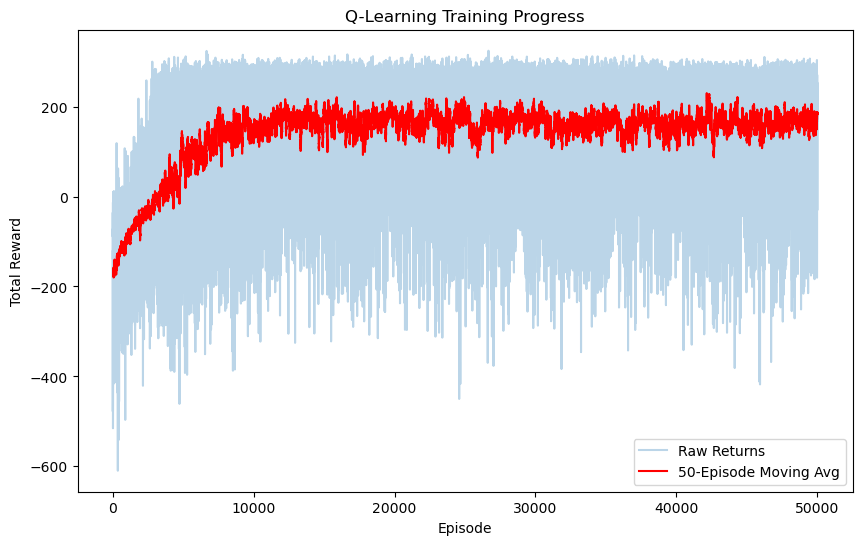

In [13]:
import matplotlib.pyplot as plt
# TODO 3.5: Plot learning curve once you have episode_returns
def plot_learning_curve(returns, window=50):
    plt.figure(figsize=(10, 6))
    plt.plot(returns, alpha=0.3, label="Raw Returns")
    moving_avg = np.convolve(returns, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(returns)), moving_avg, color='red', label=f"{window}-Episode Moving Avg")
    plt.title("Q-Learning Training Progress")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.show()

plot_learning_curve(episode_returns)

In [ ]:
# TODO 3.6: deterministic greedy policy from q_table
def q_table_greedy_policy(q_table, bins):
    # this function returns a policy function
    def policy_fn(obs):
        state_idx = discretize_observation(obs, bins)
        return np.argmax(q_table[state_idx])
    return policy_fn



In [ ]:
# TODO === 3.7 Record a trained policy video ===
print("Recording trained Q-Learning agent video...")

# final greedy policy from trained Q-table
final_policy = q_table_greedy_policy(q_table, bins)

# record video with deterministic policy (random_action=False)
video_score = record_video(video_env, final_policy, "trained_agent.mp4", random_action=False)
print(f"Video saved as 'trained_agent.mp4'. Score: {video_score}")

show_video("trained_agent.mp4")

Recording trained Q-Learning agent video...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as 'trained_agent.mp4'. Score: 222.6182635949604
